In [1]:
#load libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.utils import resample

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load dataset
df = pd.read_csv("UCI_Credit_Card.csv")
print(df.head())
print(df.columns)

   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0       0.0   

In [3]:
#Target column
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)
print(df['default'].value_counts())

default
0    23364
1     6636
Name: count, dtype: int64


In [4]:
#Data cleaning
df.drop("ID", axis=1, inplace=True)
print(df.isnull().sum())

LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64


In [5]:
#Handle imbalanced Data
majority = df[df['default'] == 0]
minority = df[df['default'] == 1]

minority_up = resample(minority,
                       replace=True,
                       n_samples=len(majority),
                       random_state=42)

df_balanced = pd.concat([majority, minority_up])
df_balanced = df_balanced.sample(frac=1, random_state=42)

print(df_balanced['default'].value_counts())

default
0    23364
1    23364
Name: count, dtype: int64


In [6]:
#Split data
X = df_balanced.drop("default", axis=1)
y = df_balanced["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
#Train Models
lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

In [15]:
#Decision Tree
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced')
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]


In [16]:
#Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [17]:
#Cross Validation
cv = StratifiedKFold(n_splits=5)
scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
print("Random Forest CV ROC-AUC:", scores.mean())

Random Forest CV ROC-AUC: 0.9818089950927413


In [18]:
#ROC-AUC Scores
print("LR ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("DT ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print("RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

LR ROC-AUC: 0.7224431145972953
DT ROC-AUC: 0.7686223186419666
RF ROC-AUC: 0.9818307098035626


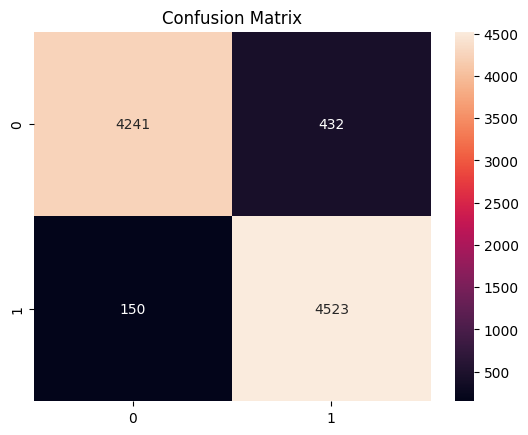

              precision    recall  f1-score   support

           0       0.97      0.91      0.94      4673
           1       0.91      0.97      0.94      4673

    accuracy                           0.94      9346
   macro avg       0.94      0.94      0.94      9346
weighted avg       0.94      0.94      0.94      9346



In [19]:
#Confusion Matrix + Recall
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred_rf))

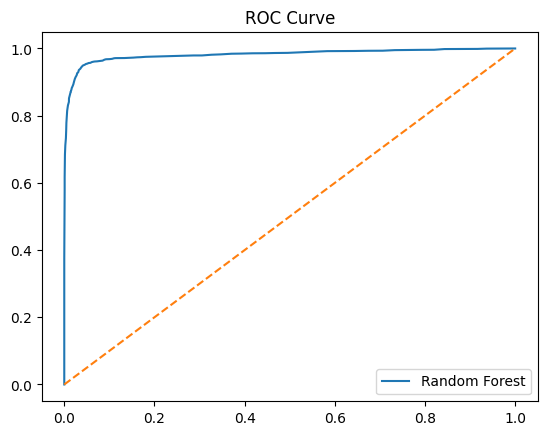

In [20]:
#ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

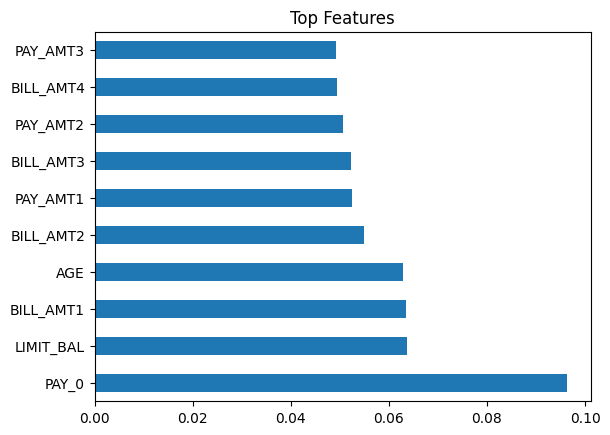

In [21]:
#Feature Importance
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns)
feat_imp.sort_values(ascending=False).head(10).plot(kind='barh')

plt.title("Top Features")
plt.show()

In [22]:
#Risk Classification
def risk_category(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

risk_levels = [risk_category(p) for p in y_prob_rf]

In [23]:
#Final Output Table
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf,
    "Probability": y_prob_rf,
    "Risk Level": risk_levels
})

print(results.head())

   Actual  Predicted  Probability   Risk Level
0       0          0         0.11     Low Risk
1       0          0         0.12     Low Risk
2       0          0         0.41  Medium Risk
3       0          0         0.19     Low Risk
4       1          1         0.92    High Risk


In [24]:
#Recommendations
def recommendation(risk):
    if risk == "High Risk":
        return "Immediate action needed"
    elif risk == "Medium Risk":
        return "Monitor closely"
    else:
        return "No action needed"

results["Recommendation"] = results["Risk Level"].apply(recommendation)